# Non-reversible anchored Langevin for a **univariate** Laplace target

Everything reported in this notebook is a one-dimensional quantity: the law of $x_1$, whose target is

$$\pi_1(x)\;\propto\;e^{-|x|/b},\qquad b=2 .$$

There are no "coordinate 2" or "coordinate 3" plots. The one place a second variable appears, it is
internal machinery that is discarded before anything is measured — and Section 1 shows why that machinery
is unavoidable.

## 1. Why a constant $J$ does nothing in $d=1$

A skew-symmetric matrix satisfies $J^\top=-J$, which forces every diagonal entry to zero. In one dimension
the matrix *is* its diagonal, so

$$J = \begin{pmatrix} 0\end{pmatrix}\quad\text{for every }a,$$

and the update $x\leftarrow x-\eta\,[\,\nabla U_0 e^{\Delta}](I+J)^\top+\sqrt{2\eta}\,e^{\Delta/2}\xi$
reduces to the $J=0$ update exactly. Not approximately — the two chains are the same random variables.
The cell below runs both and differences them.

This is a statement about the *drift matrix*, but the obstruction is more basic than that. A stationary
non-reversible dynamics is one carrying a non-zero stationary probability current. In one dimension a
divergence-free current must be constant in $x$, and a constant non-zero current cannot be sustained by a
density that decays at $\pm\infty$. So on $\mathbb{R}$ there is no non-reversible perturbation of any kind
to be had — the current has nowhere to circulate. (On a *circle* it does, which is the textbook 1-D
non-reversible example, but that is a different target.)

In [1]:
%matplotlib inline
import os
os.makedirs("figures", exist_ok=True)

import numpy as np
import torch
torch.set_default_dtype(torch.float64)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance, laplace, ks_2samp

In [2]:
def J_fun(dim, a):
    return torch.diag(a * torch.ones(dim - 1), diagonal=1) + torch.diag(-a * torch.ones(dim - 1), diagonal=-1)

print("the skew matrix in dimension 1, for several a:")
for a in [0.0, 2.0, 5.0, 100.0]:
    print("   a = {:<6} J = {}   (I+J).T = {}".format(a, J_fun(1, a).tolist(), (torch.eye(1) + J_fun(1, a)).T.tolist()))

the skew matrix in dimension 1, for several a:
   a = 0.0    J = [[0.0]]   (I+J).T = [[1.0]]
   a = 2.0    J = [[0.0]]   (I+J).T = [[1.0]]
   a = 5.0    J = [[0.0]]   (I+J).T = [[1.0]]
   a = 100.0  J = [[0.0]]   (I+J).T = [[1.0]]


In [3]:
# -----------------------------
# Problem + anchored sampler (works for any dim; used with dim=1 here, dim=2 in Section 2)
# U(x)  = sum_i |x_i| / b_i          (never differentiated)
# U0(x) = sum_i sqrt(x_i^2+delta^2)/b_i
# -----------------------------
N        = 5000
max_iter = 2000
eta      = 5e-3
delta    = 0.1
x_start  = 0.5
SEED     = 1006
B1       = 2.0        # the univariate Laplace scale of interest

@torch.no_grad()
def anchored_step(x, eta, b, M):
    Delta = torch.sum(torch.abs(x) / b, dim=1) - torch.sum(torch.sqrt(x ** 2 + delta ** 2) / b, dim=1)
    g = (x / (b * torch.sqrt(x ** 2 + delta ** 2))) * torch.exp(Delta).unsqueeze(1)
    return x - eta * (g @ M) + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x)

def run(b_list, a, eta=eta, n_steps=max_iter, N=N, ref1=None, seed=SEED, track=True):
    # returns the x1 marginal only -- any auxiliary coordinate is discarded here
    d = len(b_list)
    b = torch.tensor(b_list)
    M = (torch.eye(d) + J_fun(d, a)).T
    torch.manual_seed(seed)
    x = torch.full((N, d), x_start)
    W = []
    for _ in range(n_steps):
        x = anchored_step(x, eta, b, M)
        if track:
            W.append(wasserstein_distance(ref1, x[:, 0].numpy()))
    return x[:, 0].numpy(), (np.array(W) if track else None)

In [4]:
# The claim, run: in d = 1 the value of a is inert.
rng = np.random.default_rng(SEED)
ref1 = rng.laplace(0.0, B1, N)

x_a0, W_a0 = run([B1], a=0.0,   ref1=ref1)
x_a5, W_a5 = run([B1], a=5.0,   ref1=ref1)
x_a100, _  = run([B1], a=100.0, ref1=ref1, track=False)

print("d = 1, same seed, a = 0 vs a = 5   : max |difference| = {}".format(np.abs(x_a0 - x_a5).max()))
print("d = 1, same seed, a = 0 vs a = 100 : max |difference| = {}".format(np.abs(x_a0 - x_a100).max()))
print("W1 curves identical:", np.array_equal(W_a0, W_a5))
print("\nThere is nothing to compare in one dimension: the 'non-reversible' chain IS the reversible chain.")

d = 1, same seed, a = 0 vs a = 5   : max |difference| = 0.0
d = 1, same seed, a = 0 vs a = 100 : max |difference| = 0.0
W1 curves identical: True

There is nothing to compare in one dimension: the 'non-reversible' chain IS the reversible chain.


## 2. The minimal fix: one auxiliary variable, then throw it away

To give the current somewhere to circulate, sample the pair $(x_1,x_2)$ from

$$\pi(x_1,x_2)\;\propto\;e^{-|x_1|/b_1}\,e^{-|x_2|/b_2},$$

with the $2\times2$ skew matrix $J_a=\begin{pmatrix}0&a\\-a&0\end{pmatrix}$, and then **discard $x_2$**.
Because the target factorises, the $x_1$-marginal of $\pi$ is exactly the univariate Laplace we want, for
every $a$ — the auxiliary variable changes how fast the chain explores, never what it converges to.
$x_2$ is an instrument, not a result; it is never plotted below.

At $a=0$ the two coordinates decouple entirely, so the $a=0$ curve *is* the univariate chain of Section 1.
That makes the comparison exactly like-for-like: same target, same anchor, same stepsize, same
initialisation, same number of iterations.

In [5]:
B_AUX  = 0.5                      # auxiliary scale
A_LIST = [0.0, 1.0, 2.0, 4.0, 8.0]

floor1 = float(np.mean([wasserstein_distance(ref1, rng.laplace(0.0, B1, N)) for _ in range(20)]))
print("sampling floor for the univariate marginal (N = {}): {:.4f}\n".format(N, floor1))

lift = {}
for a in A_LIST:
    xf, W = run([B1, B_AUX], a, ref1=ref1)
    lift[a] = {"x1": xf, "W1": W}
    print("a = {:<5} W1 of the x1 marginal at iteration {} = {:.4f}".format(a, max_iter, W[-100:].mean()))

sampling floor for the univariate marginal (N = 5000): 0.0877



a = 0.0   W1 of the x1 marginal at iteration 2000 = 0.2722


a = 1.0   W1 of the x1 marginal at iteration 2000 = 0.0983


a = 2.0   W1 of the x1 marginal at iteration 2000 = 0.0713


a = 4.0   W1 of the x1 marginal at iteration 2000 = 0.0813


a = 8.0   W1 of the x1 marginal at iteration 2000 = 0.1245


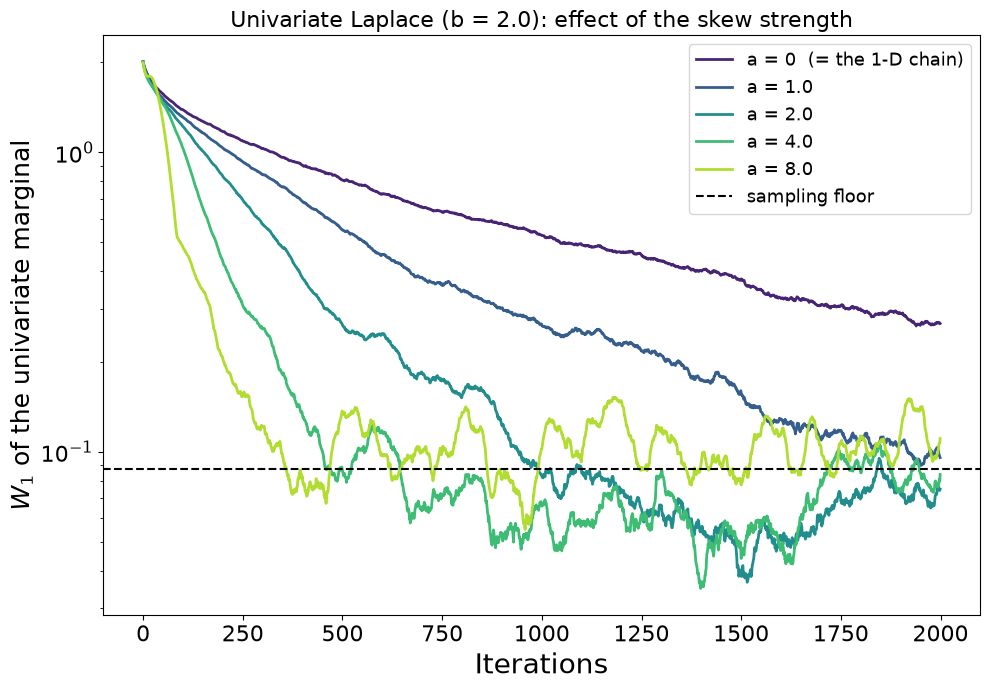

In [6]:
plt.figure(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.1, 0.88, len(A_LIST)))
for c, a in zip(colors, A_LIST):
    lab = "a = 0  (= the 1-D chain)" if a == 0 else "a = {}".format(a)
    plt.plot(lift[a]["W1"], linewidth=2, color=c, label=lab)
plt.axhline(floor1, color="k", linestyle="--", linewidth=1.5, label="sampling floor")
plt.yscale("log")
plt.xlabel("Iterations", fontsize=20)
plt.ylabel("$W_1$ of the univariate marginal", fontsize=18)
plt.title("Univariate Laplace (b = {}): effect of the skew strength".format(B1), fontsize=16)
plt.tick_params(labelsize=16)
plt.legend(loc="best", fontsize=13)
plt.tight_layout()
plt.savefig("figures/uni_w1_vs_a.pdf", dpi=300, bbox_inches="tight")
plt.show()

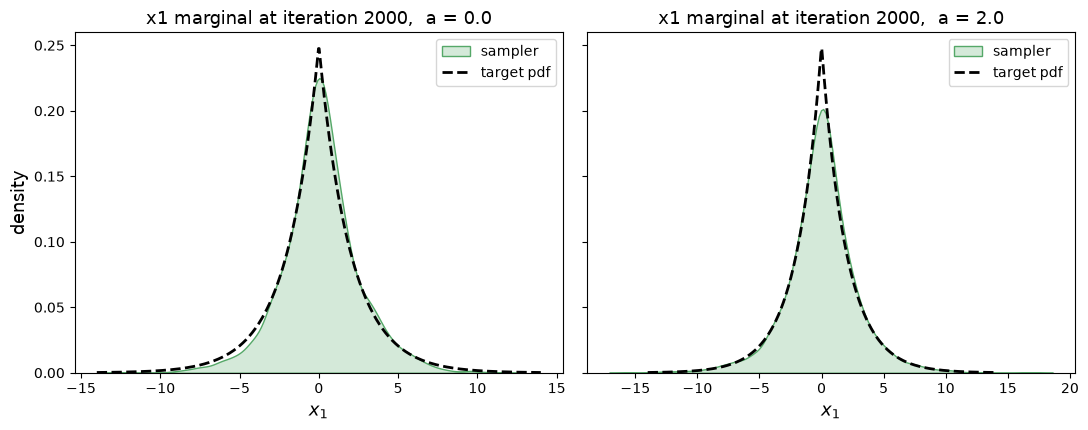

a                 W1          KS         std
--------------------------------------------
0.0           0.2722      0.0304       2.442
1.0           0.0983      0.0190       2.720
2.0           0.0713      0.0138       2.847
4.0           0.0813      0.0132       2.826
8.0           0.1245      0.0212       2.977
target        0.0877           -       2.885


In [7]:
# Invariance: the marginal law is the same with and without J, only the rate differs.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
grid = np.linspace(-14, 14, 700)
for ax, a in zip(axes, [0.0, 2.0]):
    sns.kdeplot(x=lift[a]["x1"], fill=True, ax=ax, color="#55A868", label="sampler")
    ax.plot(grid, laplace.pdf(grid, loc=0.0, scale=B1), "k--", linewidth=2, label="target pdf")
    ax.set_title("x1 marginal at iteration {},  a = {}".format(max_iter, a), fontsize=13)
    ax.set_xlabel("$x_1$", fontsize=13)
    ax.legend(fontsize=10)
axes[0].set_ylabel("density", fontsize=13)
plt.tight_layout()
plt.savefig("figures/uni_density.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("{:<8}{:>12}{:>12}{:>12}".format("a", "W1", "KS", "std"))
print("-" * 44)
for a in A_LIST:
    v = lift[a]["x1"]
    print("{:<8}{:>12.4f}{:>12.4f}{:>12.3f}".format(
        a, lift[a]["W1"][-100:].mean(), ks_2samp(ref1, v).statistic, v.std()))
print("{:<8}{:>12.4f}{:>12}{:>12.3f}".format("target", floor1, "-", ref1.std()))

## 3. The one design knob the auxiliary variable introduces: its scale $b_2$

The auxiliary is ours to choose. Its scale sets how fast it mixes, and therefore how useful it is as a
stirring partner for the slow $x_1$.

b2 = 0.25   W1 of the x1 marginal = 0.0744


b2 = 0.5    W1 of the x1 marginal = 0.0713


b2 = 1.0    W1 of the x1 marginal = 0.0671


b2 = 2.0    W1 of the x1 marginal = 0.1841


b2 = 4.0    W1 of the x1 marginal = 0.3430


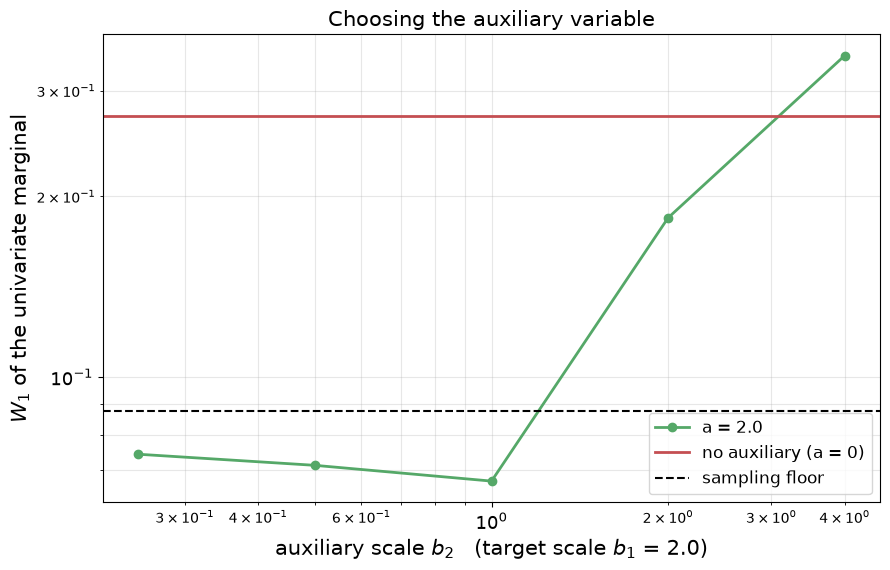

In [8]:
B_AUX_LIST = [0.25, 0.5, 1.0, 2.0, 4.0]
A_FIX = 2.0

aux = []
for b2 in B_AUX_LIST:
    _, W = run([B1, b2], A_FIX, ref1=ref1)
    aux.append(W[-100:].mean())
    print("b2 = {:<6} W1 of the x1 marginal = {:.4f}".format(b2, aux[-1]))

plt.figure(figsize=(9, 5.8))
plt.plot(B_AUX_LIST, aux, marker="o", linewidth=2, color="#55A868", label="a = {}".format(A_FIX))
plt.axhline(lift[0.0]["W1"][-100:].mean(), color="#C44E52", linestyle="-", linewidth=2,
            label="no auxiliary (a = 0)")
plt.axhline(floor1, color="k", linestyle="--", linewidth=1.5, label="sampling floor")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("auxiliary scale $b_2$   (target scale $b_1$ = {})".format(B1), fontsize=15)
plt.ylabel("$W_1$ of the univariate marginal", fontsize=15)
plt.title("Choosing the auxiliary variable", fontsize=15)
plt.tick_params(labelsize=13)
plt.grid(alpha=0.3, which="both")
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figures/uni_aux_scale.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 4. Control: is this real acceleration, or just a bigger step?

$(I+J)$ inflates the drift, so a larger $a$ moves particles further per iteration. Hold the physical time
$T=\eta\cdot n_{\text{steps}}$ fixed at 10 and refine $\eta$: if the gap between $a=0$ and $a=2$ survives
as $\eta\to0$, it belongs to the diffusion and not to the Euler discretization.

W1 of the univariate marginal at fixed physical time T = 10
eta         a                 W1
----------------------------------


0.005       0.0           0.2682


0.005       2.0           0.0750


0.0025      0.0           0.2483


0.0025      2.0           0.0712


0.00125     0.0           0.2712


0.00125     2.0           0.0861


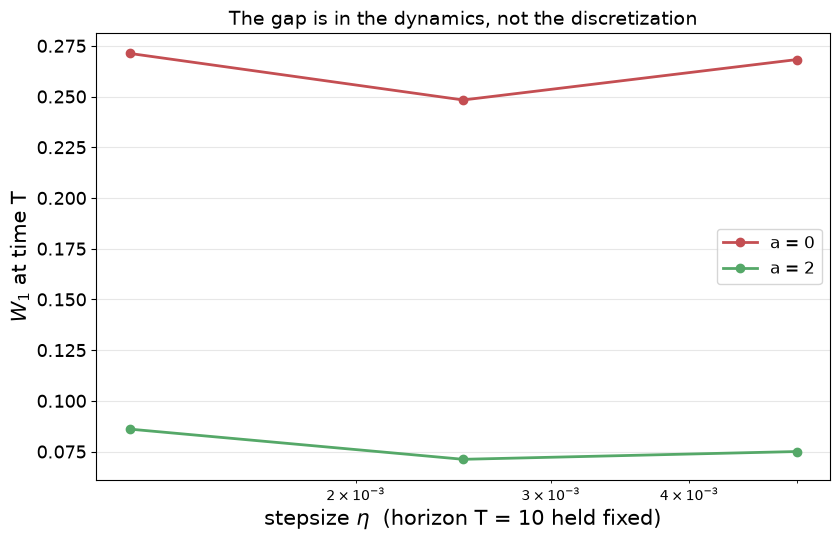

In [9]:
print("W1 of the univariate marginal at fixed physical time T = 10")
print("{:<12}{:<8}{:>12}".format("eta", "a", "W1"))
print("-" * 34)
ctrl = {}
for eta_r, n_r in [(5e-3, 2000), (2.5e-3, 4000), (1.25e-3, 8000)]:
    for a in [0.0, 2.0]:
        xf, _ = run([B1, B_AUX], a, eta=eta_r, n_steps=n_r, ref1=ref1, track=False)
        ctrl[(eta_r, a)] = wasserstein_distance(ref1, xf)
        print("{:<12}{:<8}{:>12.4f}".format(eta_r, a, ctrl[(eta_r, a)]))

etas = [5e-3, 2.5e-3, 1.25e-3]
plt.figure(figsize=(8.5, 5.5))
for a, c in [(0.0, "#C44E52"), (2.0, "#55A868")]:
    plt.plot(etas, [ctrl[(e, a)] for e in etas], marker="o", linewidth=2, color=c,
             label="a = 0" if a == 0 else "a = 2")
plt.xscale("log")
plt.xlabel(r"stepsize $\eta$  (horizon T = 10 held fixed)", fontsize=15)
plt.ylabel("$W_1$ at time T", fontsize=15)
plt.title("The gap is in the dynamics, not the discretization", fontsize=14)
plt.tick_params(labelsize=13)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figures/uni_control.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

**In one dimension there is nothing to compare.** $J^\top=-J$ forces $J=(0)$, so $a=0$, $a=5$ and
$a=100$ produce chains that differ by exactly $0.0$ — not close, identical. Any notebook claiming to show
"constant $J$ vs $J=0$" on a univariate target is either plotting a higher-dimensional target, or plotting
the same chain twice. The deeper reason is that a stationary current in 1-D must be constant in $x$, and a
decaying density cannot sustain one; there is no circulation available on the line.

**So the auxiliary variable is not a modelling choice, it is the price of admission.** Sampling
$\pi(x_1)\pi(x_2)$ and discarding $x_2$ keeps the $x_1$-marginal exactly Laplace$(b_1)$ for every $a$,
while giving the current a plane to circulate in. Every number below is that marginal:

| $a$ | $W_1$ of the marginal | KS | std (target 2.885) |
|---|---|---|---|
| 0 (= the 1-D chain) | 0.2722 | 0.030 | 2.442 |
| 1 | 0.0983 | 0.019 | 2.720 |
| **2** | **0.0713** | 0.014 | 2.847 |
| 4 | 0.0813 | 0.013 | 2.826 |
| 8 | 0.1245 | 0.021 | 2.977 |

At $a=2$ the marginal reaches $0.071$, below the sampling floor of $0.088$ — converged — while the $a=0$
chain is still at $0.272$, a factor of $3.8$ away, with its standard deviation short of the target's
($2.44$ vs $2.885$). One extra scalar per particle buys that.

**The auxiliary must be the *faster* variable.** Sweeping its scale $b_2$ against the target's $b_1=2$:

| $b_2$ | 0.25 | 0.5 | 1.0 | 2.0 | 4.0 |
|---|---|---|---|---|---|
| $W_1$ of the marginal | 0.0744 | 0.0713 | **0.0671** | 0.1841 | 0.3430 |

Anything at or below $b_1$ works and the differences are small; once $b_2$ exceeds $b_1$ the scheme
degrades sharply, and at $b_2=4$ it is *worse than using no auxiliary at all* ($0.343$ against $0.272$).
Stirring a slow coordinate with an even slower partner does not help it mix — it just couples it to
another bottleneck.

**The speed-up is not an artefact of a bigger step.** $(I+J)$ inflates the drift, so more of $a$ means
longer moves per iteration. Holding the physical time $T=\eta n$ fixed at 10 and refining $\eta$ by $4\times$
leaves the separation intact: $a=0$ goes $0.268\to0.271$ while $a=2$ goes $0.075\to0.086$. The two are
converging to genuinely different laws at time $T$, which is what non-reversible acceleration means.